# Module 1d - Bring Your Own Table: upload, pick two columns, get a model

The most common place people get stuck is not the model, it is **getting their own data in**. This module removes that wall. You click a button, choose a file **from your computer**, tell it **which columns are the inputs** and **which one column is the output**, and it trains an ensemble model and shows you the result. No chemistry assumptions, no manual featurizing: any table works.

It handles the messy parts for you: it reads common table files, turns text columns into features, fills in missing values, and decides regression vs classification on its own. You only ever edit **two lines** (Section 2). Everything else runs as is.

- **Model:** Random Forest and XGBoost, plus their committee average. Ensembles are the reliable default for tabular data, and both are easy to swap.
- **Runs with no upload too:** if you do not pick a file, it falls back to a shipped example table so the notebook always produces a result.

## 0. Setup

In [1]:
# Colab setup: fetch the repo and enter this module's folder. No-op when run locally.
import os, sys
REPO = "https://github.com/ruiding-uchicago/NRT_Training_Materials.git"
MODULE = "module_1_tabular_ML"
if "google.colab" in sys.modules and os.path.basename(os.getcwd()) != MODULE:
    root = "/content/NRT_Training_Materials"
    if not os.path.isdir(root):
        os.system("git clone --depth 1 " + REPO + " " + root)
    os.chdir(root + "/" + MODULE)
print("ready in", os.getcwd())

ready in /Users/ruiding/mac_python_folder/NRT_training_materials_RD_June2026/module_1_tabular_ML


In [2]:
import sys, subprocess
# scikit-learn + xgboost + shap do the modeling; openpyxl lets pandas read .xlsx. Install on Colab (no-op locally).
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "scikit-learn", "xgboost", "shap", "openpyxl"])

## 1. Upload your table

Run the cell and **click the button**, then choose a file from your computer. No file handy? Just cancel the dialog and it uses a bundled example. Ten ready-to-try tables are in **`sample_data/`** - download one to your computer, then upload it here to find your field and rehearse the flow before using your own data:

| file | field | predict | task |
|---|---|---|---|
| `molecules_solubility_regression.xlsx` | molecules | aqueous solubility · Excel template | regression |
| `battery_electrolyte_regression.csv` | battery electrolytes | ionic conductivity | regression |
| `superconductor_Tc_regression.csv` | superconductors | critical temperature | regression |
| `superhard_modulus_regression.csv` | superhard materials | bulk modulus | regression |
| `high_entropy_alloy_hardness_regression.csv` | high-entropy alloys | hardness | regression |
| `twodim_materials_bandgap_regression.csv` | 2D materials | band gap | regression |
| `mof_co2_capture_regression.csv` | MOFs / carbon capture | CO2 uptake | regression |
| `dielectrics_ferroelectric_classification.csv` | dielectrics | ferroelectric or not | classification |
| `molecules_biodegradability_classification.csv` | molecules | biodegradable or not | classification |
| `perovskite_oxide_metal_insulator_classification.csv` | perovskite oxides | metal or insulator | classification |

Every file has its **target in the last column**, so it runs with no edits; change the lines in Section 2 to try other columns.

In [3]:
import io, sys, pandas as pd

def read_table(name, data):
    """Read bytes from any common table file, trying encodings and delimiters."""
    if name.lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(io.BytesIO(data))
    for enc in ("utf-8", "gbk", "latin-1"):
        try:
            return pd.read_csv(io.BytesIO(data), sep=None, engine="python", encoding=enc)
        except Exception:
            continue
    return pd.read_csv(io.BytesIO(data))

df, source = None, None
if "google.colab" in sys.modules:
    from google.colab import files
    print("Click the button and choose a file from your computer (or cancel to use a bundled example).")
    up = files.upload()
    if up:
        nm = list(up)[0]; df = read_table(nm, up[nm]); source = "YOUR file  ->  " + nm
if df is None:
    with open("sample_data/battery_electrolyte_regression.csv", "rb") as f:
        df = read_table("battery_electrolyte_regression.csv", f.read())
    source = "BUNDLED EXAMPLE (battery electrolyte)  --  no file was uploaded, re-run this cell to upload yours"

df.columns = [str(c).strip() for c in df.columns]
print("\n" + "=" * 64)
print("LOADED:", source)
print(f"{df.shape[0]} rows  x  {df.shape[1]} columns")
if str(df.columns[0]).lower().startswith("unnamed"):
    print("!! The first column is 'Unnamed' - your header row may not be the first row.")
    print("   Delete any title/units rows above the header in your file and re-upload.")
eu = [c for c in df.columns if df[c].dtype == object
      and df[c].astype(str).str.match(r"^-?\d+,\d+$").mean() > 0.5]
if eu:
    print("!! Columns", eu, "look like European decimals (comma). Re-save with '.' as the")
    print("   decimal point, or the numbers may be misread.")
print("=" * 64)
df.head()


LOADED: BUNDLED EXAMPLE (battery electrolyte)  --  no file was uploaded, re-run this cell to upload yours
3000 rows  x  14 columns


,temperature_K,salt_conc,salt,PC,DEC,EC,EMC,EA,DME,Sulfolane,TFP,DMC,2-MeTHF,conductivity_S_cm
0,233.75,1.508621,LiBF4,0.6,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.188235
1,323.15,1.265421,LiPF6,0.0,0.0,0.3,0.7,0.0,0.0,0.0,0.0,0.0,0.0,12.891429
2,312.45,2.126500,LiPF6,0.7,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.568000
3,243.65,1.477600,LiPF6,0.3,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.788700
4,332.15,1.711560,LiPF6,0.3,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.548996


## 2. Pick your columns  ·  EDIT HERE

This is the only cell you change. Set the one column to predict, and the columns to predict from.

In [4]:
# your columns (name  ·  type  ·  #distinct  ·  example) - use the names below:
for i, c in enumerate(df.columns):
    ex = df[c].dropna().iloc[0] if df[c].notna().any() else ""
    print(f"[{i}] {c}   ({df[c].dtype}, {df[c].nunique()} distinct, e.g. {ex})")

# ==================  EDIT THESE LINES  ==================
OUTPUT_COLUMN = df.columns[-1]     # the ONE column to predict. default = the LAST column above
INPUT_COLUMNS = None               # columns to predict FROM. None = every other column. e.g. ["temp", "time", "metal"]
TASK_OVERRIDE = None               # leave None to auto-detect; or force "regression" / "classification"
# =======================================================

target = OUTPUT_COLUMN
assert target in df.columns, f"OUTPUT_COLUMN '{target}' is not a column. Pick one of: {list(df.columns)}"
if df[target].dtype == object and df[target].nunique() > 0.8 * len(df):
    print(f"\n!! '{target}' has {df[target].nunique()} distinct text values - it looks like notes/IDs, not a")
    print("   target to predict. If so, set OUTPUT_COLUMN above to your real target column.")
features = list(INPUT_COLUMNS) if INPUT_COLUMNS else [c for c in df.columns if c != target]
bad = [c for c in features if c not in df.columns]
assert not bad, f"These INPUT_COLUMNS are not columns: {bad}.  Columns are: {list(df.columns)}"
print("\npredict      :", target)
print("from columns :", features)

[0] temperature_K   (float64, 318 distinct, e.g. 233.75)
[1] salt_conc   (float64, 1739 distinct, e.g. 1.50862069)
[2] salt   (object, 14 distinct, e.g. LiBF4)
[3] PC   (float64, 25 distinct, e.g. 0.6)
[4] DEC   (float64, 9 distinct, e.g. 0.4)
[5] EC   (float64, 24 distinct, e.g. 0.0)
[6] EMC   (float64, 15 distinct, e.g. 0.0)
[7] EA   (float64, 8 distinct, e.g. 0.0)
[8] DME   (float64, 10 distinct, e.g. 0.0)
[9] Sulfolane   (float64, 9 distinct, e.g. 0.0)
[10] TFP   (float64, 6 distinct, e.g. 0.0)
[11] DMC   (float64, 12 distinct, e.g. 0.0)
[12] 2-MeTHF   (float64, 9 distinct, e.g. 0.0)
[13] conductivity_S_cm   (float64, 2901 distinct, e.g. 0.188235294)

predict      : conductivity_S_cm
from columns : ['temperature_K', 'salt_conc', 'salt', 'PC', 'DEC', 'EC', 'EMC', 'EA', 'DME', 'Sulfolane', 'TFP', 'DMC', '2-MeTHF']


## 3. Turn the table into numbers  (automatic)

Numeric columns pass through. Text columns with a small number of distinct values become one-hot features. High-cardinality text (ids, names, free text) is dropped with a note. Missing values are filled, rows with no target are removed, and the task (regression vs classification) is decided from the output column.

In [5]:
import numpy as np, pandas as pd, re
MAX_CAT = 20        # a text column with more distinct values than this is treated as an id and dropped

Xraw = df[features].copy(); y = df[target]
keep = y.notna(); Xraw, y = Xraw[keep], y[keep]                      # drop rows with no target

# target stored as text but really numeric ("85%", "1,234") -> numbers
if not pd.api.types.is_numeric_dtype(y):
    y_try = pd.to_numeric(y.astype(str).str.replace(r"[,%\s]", "", regex=True), errors="coerce")
    if y_try.notna().mean() >= 0.9:
        y = y_try; k2 = y.notna(); Xraw, y = Xraw[k2], y[k2]
        print("note: target looked like text but is numeric - treating as a number (stripped % , spaces).")

# feature column stored as text with a unit ("5 mg", "3.2 V") -> pull the number out
for c in list(Xraw.columns):
    if Xraw[c].dtype == object:
        pulled = pd.to_numeric(Xraw[c].astype(str).str.extract(r"([-+]?\d*\.?\d+)")[0], errors="coerce")
        if pulled.notna().mean() >= 0.9:
            Xraw[c] = pulled

# drop obvious identifier columns (a real feature is almost never all-unique text/ints)
id_like = re.compile(r"^(id|index|idx|uuid|unnamed.*)$|_id$", re.I)
def looks_id(c):
    col = Xraw[c]
    if id_like.search(str(c).strip()): return True
    if col.nunique() == len(Xraw) and (col.dtype == object or pd.api.types.is_integer_dtype(col)): return True
    return False
id_cols = [c for c in Xraw.columns if looks_id(c)]
Xraw = Xraw.drop(columns=id_cols)

num     = Xraw.select_dtypes(include="number").columns.tolist()
cat_all = [c for c in Xraw.columns if c not in num]
cat     = [c for c in cat_all if Xraw[c].nunique(dropna=True) <= MAX_CAT]
dropped_text = [c for c in cat_all if c not in cat]

def make_X(frame):                      # reusable: raw feature frame -> model-ready numeric columns
    F = frame.drop(columns=[c for c in id_cols if c in frame.columns], errors="ignore")
    Fx = pd.get_dummies(F[[c for c in (num + cat) if c in F.columns]], columns=[c for c in cat if c in F.columns], dummy_na=False)
    Fx.columns = [re.sub(r"[\[\]<>]", "_", str(col)) for col in Fx.columns]
    return Fx

X = make_X(Xraw).apply(pd.to_numeric, errors="coerce")
allnan = X.isna().all(axis=1)                 # a row with no usable feature value at all
if allnan.any(): X, y = X[~allnan], y[~allnan]
n_impute = int(X.isna().sum().sum())          # remaining missing feature cells -> median-filled
TRAIN_MED = X.median(numeric_only=True)
X = X.fillna(TRAIN_MED).fillna(0.0)

is_num = pd.api.types.is_numeric_dtype(y)
TASK = TASK_OVERRIDE or ("regression" if (is_num and y.nunique() > 10) else "classification")

assert X.shape[1] > 0, ("No usable feature columns were left. Your inputs were all text with too many "
                        "distinct values. Put your numeric columns in INPUT_COLUMNS (Section 2).")
print(f"task         : {TASK}" + ("  (auto-detected)" if not TASK_OVERRIDE else "  (forced by TASK_OVERRIDE)"))
print(f"features used: {X.shape[1]} columns  ({len(num)} numeric + one-hot of {cat if cat else 'none'})")
if id_cols:      print(f"dropped ids  : {id_cols}")
if dropped_text: print(f"dropped text : {dropped_text}  (too many distinct values)")
n_skipped = len(df) - len(X)
print(f"samples      : {len(X)}  (kept)")
if n_skipped: print(f"skipped rows : {n_skipped}  (missing or invalid target, or an all-empty row)")
if n_impute:  print(f"filled cells : {n_impute}  missing feature values, median-filled")
if len(X) < 20:
    print("!! very few rows (<20) - metrics will be unreliable; treat the result as a rough sketch.")
print(f"\n>>> about to train to predict '{target}' as {TASK}, from {X.shape[1]} features on {len(X)} rows.")
print(">>> if that is not what you meant, fix Section 2 and re-run from there.")

task         : regression  (auto-detected)
features used: 26 columns  (12 numeric + one-hot of ['salt'])
samples      : 3000  (kept)

>>> about to train to predict 'conductivity_S_cm' as regression, from 26 features on 3000 rows.
>>> if that is not what you meant, fix Section 2 and re-run from there.


## 4. Train the ensemble  (Random Forest + XGBoost)

An 80/20 split, two tree ensembles, and their committee average. Regression is scored by R2 and MAE; classification by accuracy and macro-F1.

The score is measured on the untouched 20% test split, so it reflects performance on new data, not memorization.

In [6]:
from sklearn.model_selection import train_test_split
RND = 0

if TASK == "regression":
    from sklearn.ensemble import RandomForestRegressor
    from xgboost import XGBRegressor
    from sklearn.metrics import r2_score, mean_absolute_error
    Xtr, Xte, ytr, yte = train_test_split(X, y.astype(float), test_size=0.2, random_state=RND)
    models = {"RandomForest": RandomForestRegressor(n_estimators=400, random_state=RND, n_jobs=-1),
              "XGBoost":      XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5,
                                           subsample=0.8, colsample_bytree=0.8, random_state=RND, n_jobs=-1)}
    preds = {}
    for n, m in models.items():
        m.fit(Xtr, ytr); preds[n] = m.predict(Xte)
        print(f"{n:13s} R2={r2_score(yte, preds[n]):.3f}   MAE={mean_absolute_error(yte, preds[n]):.3g}")
    ens = np.mean(list(preds.values()), axis=0)
    print(f"{'Committee':13s} R2={r2_score(yte, ens):.3f}   MAE={mean_absolute_error(yte, ens):.3g}")
    print("guide: R2 > 0.8 strong  ·  0.5-0.8 useful  ·  < 0.3 weak (little signal in these columns)")
else:
    from sklearn.ensemble import RandomForestClassifier
    from xgboost import XGBClassifier
    from sklearn.metrics import accuracy_score, f1_score
    vc = y.value_counts(); rare = vc[vc < 2].index.tolist()
    if rare:
        good = ~y.isin(rare); X, y = X[good], y[good]
        print(f"dropped rare classes with <2 rows (cannot be split): {rare}")
    ycat = y.astype("category"); classes = list(ycat.cat.categories); ycode = ycat.cat.codes
    strat = ycode if ycode.value_counts().min() >= 2 else None
    Xtr, Xte, ytr, yte = train_test_split(X, ycode, test_size=0.2, random_state=RND, stratify=strat)
    models = {"RandomForest": RandomForestClassifier(n_estimators=400, random_state=RND, n_jobs=-1),
              "XGBoost":      XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=5,
                                            subsample=0.8, colsample_bytree=0.8, random_state=RND, n_jobs=-1)}
    preds = {}
    for n, m in models.items():
        m.fit(Xtr, ytr); preds[n] = m.predict(Xte)
        print(f"{n:13s} accuracy={accuracy_score(yte, preds[n]):.3f}   macro-F1={f1_score(yte, preds[n], average='macro'):.3f}")
    base = pd.Series(yte).value_counts(normalize=True).max()
    print(f"majority-class baseline = {base:.3f}  (a useful model must beat this)")
    print(f"classes: {classes}")

RandomForest  R2=0.880   MAE=0.636


XGBoost       R2=0.925   MAE=0.576
Committee     R2=0.916   MAE=0.566
guide: R2 > 0.8 strong  ·  0.5-0.8 useful  ·  < 0.3 weak (little signal in these columns)


## 5. See the result

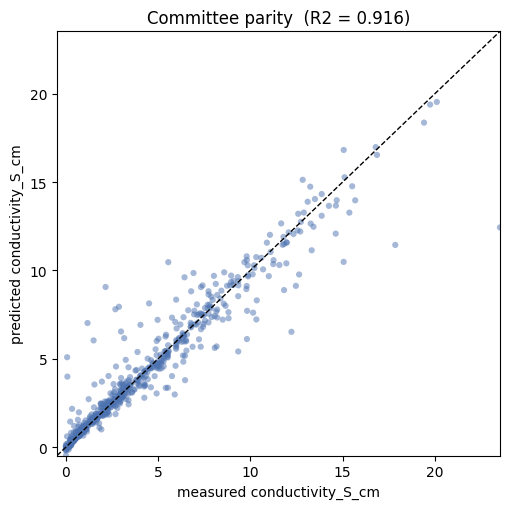

In [7]:
import matplotlib.pyplot as plt
os.makedirs("figures", exist_ok=True)

if TASK == "regression":
    fig, ax = plt.subplots(figsize=(5.2, 5.2))
    lims = [min(yte.min(), ens.min()), max(yte.max(), ens.max())]
    ax.scatter(yte, ens, s=20, alpha=0.5, color="#4C72B0", edgecolor="none")
    ax.plot(lims, lims, "k--", lw=1)
    ax.set(xlim=lims, ylim=lims, xlabel=f"measured {target}", ylabel=f"predicted {target}",
           title=f"Committee parity  (R2 = {r2_score(yte, ens):.3f})")
    fig.tight_layout(); fig.savefig("figures/1d_result.png", dpi=140); plt.show()
else:
    from sklearn.metrics import confusion_matrix
    m = models["RandomForest"]; cm = confusion_matrix(yte, preds["RandomForest"])
    fig, ax = plt.subplots(figsize=(5.6, 5.0))
    im = ax.imshow(cm, cmap="Blues")
    ax.set(xticks=range(len(classes)), yticks=range(len(classes)),
           xticklabels=classes, yticklabels=classes,
           xlabel="predicted", ylabel="actual", title="Confusion matrix (RandomForest)")
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black")
    fig.tight_layout(); fig.savefig("figures/1d_result.png", dpi=140); plt.show()

## 6. Which columns matter

Feature importance from the model. When SHAP is available it is used (it shows direction and magnitude); otherwise the model's built-in importances are shown. Either way, this is what to report and what to probe next.

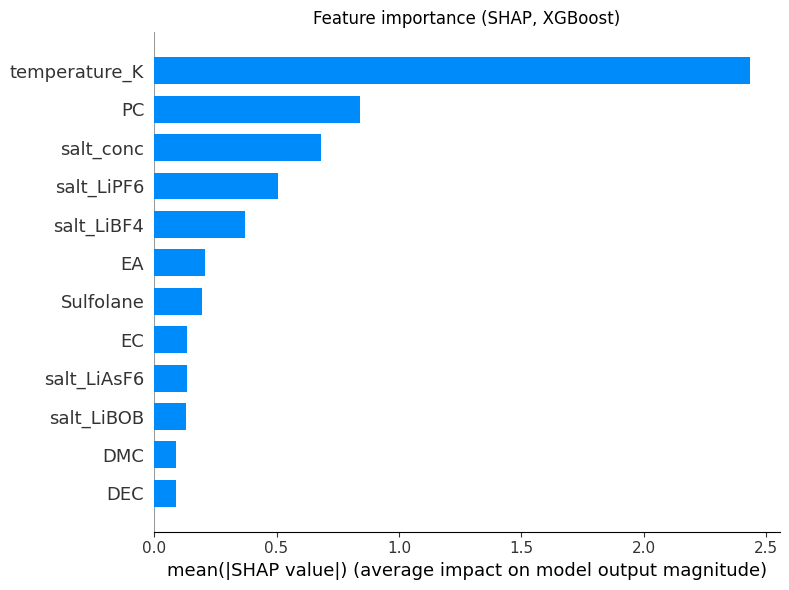

Top drivers (most influential columns): ['salt_LiBF4', 'temperature_K', 'salt_LiPF6', 'PC', 'salt_LiBOB']


In [8]:
import matplotlib.pyplot as plt
xgb = models["XGBoost"]
Xs = Xte.sample(min(300, len(Xte)), random_state=RND)
try:
    import shap
    sv = shap.TreeExplainer(xgb).shap_values(Xs)
    shap.summary_plot(sv, Xs, plot_type="bar", max_display=12, show=False)
    plt.gcf().set_size_inches(8, 6); plt.title("Feature importance (SHAP, XGBoost)")
    plt.tight_layout(); plt.savefig("figures/1d_importance.png", dpi=140, bbox_inches="tight"); plt.show()
except Exception as e:
    imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values().tail(12)
    fig, ax = plt.subplots(figsize=(8, 6)); ax.barh(imp.index, imp.values, color="#55A868")
    ax.set_title("Feature importance (XGBoost built-in)"); fig.tight_layout()
    fig.savefig("figures/1d_importance.png", dpi=140, bbox_inches="tight"); plt.show()
    print("(SHAP unavailable, used built-in importances:", e, ")")

top = pd.Series(xgb.feature_importances_, index=X.columns).nlargest(5)
print("Top drivers (most influential columns):", list(top.index))

## 7. Predict a new sample

The next question after a model is "what does it predict for a new one?" Edit the values below (it starts from a real row as a template) and run.

In [9]:
new = df[features].iloc[[0]].copy()      # template = the first row; overwrite what you change
# e.g.:  new["temperature_K"] = 298.15      # a number
#        new["salt"] = "LiPF6"              # a category, exactly as it appears in the data
Xnew = make_X(new).reindex(columns=X.columns, fill_value=0)
Xnew = Xnew.apply(pd.to_numeric, errors="coerce").fillna(TRAIN_MED).fillna(0.0)
if TASK == "regression":
    yhat = float(np.mean([m.predict(Xnew)[0] for m in models.values()]))
    print(f"predicted {target}: {yhat:.4g}")
else:
    code = models["RandomForest"].predict(Xnew)[0]
    print(f"predicted {target}: {classes[code]}")

predicted conductivity_S_cm: 0.1328


## 8. Make it yours

- **Your data:** re-run Section 1, click the button, pick your file.
- **Your columns:** change the two lines in Section 2. Set `OUTPUT_COLUMN` to what you want to predict, and either leave `INPUT_COLUMNS = None` to use everything else or list the exact columns.
- **Everything else is automatic:** numeric vs text handling, missing values, regression vs classification, and the ensemble.
- **Swap the model** in Section 4 if you like; the rest of the notebook does not care which regressor or classifier you use.

This is the fastest path from a spreadsheet to a first model and an honest importance plot. When you outgrow it (element-aware features, uncertainty, active learning), Modules 1a to 1c show the next steps.